In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import defaultdict
from tqdm import tqdm
tqdm.pandas()

from collections import Counter
from itertools import combinations

# Настройки
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Загрузка данныхs
df_cheques = pd.read_csv('../data/temp_data_cheque_50.csv')
df_products = pd.read_csv('../data/temp_data_art_name_50.csv')

print("ЗАГРУЗКА ДАННЫХ ЗАВЕРШЕНА")

ЗАГРУЗКА ДАННЫХ ЗАВЕРШЕНА


In [3]:
df_cheques.head(2)

,summ_discounted,cheque_id,contact_id
0,1538.63,5.991746e+09,55120515.0
1,3821.45,6.042741e+09,12583924.0


In [4]:
df_products.head(2)

,cheque_id,item_number,quantity,name,art_grp_lvl_0_name,art_grp_lvl_1_name,art_grp_lvl_2_name,art_grp_lvl_3_name,art_grp_lvl_4_name,art_grp_name,art_grp_full_name,grp_art_full_name,art_pricing_model
0,5.854260e+09,NaN,1.0,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь,Коньяк,Коньяк Армения,Коньяк Армения до 5 лет,Коньяк Армения до 5 лет,Коньяк Армения до 5 лет,Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Продукты
1,5.880308e+09,NaN,1.0,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь,Коньяк,Коньяк Армения,Коньяк Армения до 5 лет,Коньяк Армения до 5 лет,Коньяк Армения до 5 лет,Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Продукты


In [5]:
print("\n БАЗОВАЯ ИНФОРМАЦИЯ О ЧЕКАХ:")
print(f"   Всего строк в чеках: {len(df_cheques):,}")
print(f"   Всего столбцов: {len(df_cheques.columns)}")
print(f"   Столбцы: {list(df_cheques.columns)}")

print("\n БАЗОВАЯ ИНФОРМАЦИЯ О ТОВАРАХ:")
print(f"   Всего строк в товарах: {len(df_products):,}")
print(f"   Всего столбцов: {len(df_products.columns)}")
print(f"   Столбцы: {list(df_products.columns)}")


 БАЗОВАЯ ИНФОРМАЦИЯ О ЧЕКАХ:
   Всего строк в чеках: 50,000
   Всего столбцов: 3
   Столбцы: ['summ_discounted', 'cheque_id', 'contact_id']

 БАЗОВАЯ ИНФОРМАЦИЯ О ТОВАРАХ:
   Всего строк в товарах: 804,737
   Всего столбцов: 13
   Столбцы: ['cheque_id', 'item_number', 'quantity', 'name', 'art_grp_lvl_0_name', 'art_grp_lvl_1_name', 'art_grp_lvl_2_name', 'art_grp_lvl_3_name', 'art_grp_lvl_4_name', 'art_grp_name', 'art_grp_full_name', 'grp_art_full_name', 'art_pricing_model']


In [6]:
print("\n СОЕДИНЕНИЕ ДАННЫХ ПО cheque_id...")
df = df_products.merge(df_cheques, on='cheque_id', how='left')
print(f"   Объединённая таблица: {len(df):,} строк")


 СОЕДИНЕНИЕ ДАННЫХ ПО cheque_id...
   Объединённая таблица: 804,737 строк


In [7]:
bad_treshold = df.groupby('cheque_id')['quantity'].count().reset_index().sort_values('quantity')
bad_treshold_lst = bad_treshold[(bad_treshold.quantity==1) | (bad_treshold.quantity>100)]['cheque_id'].tolist()

In [8]:
print("\n УНИКАЛЬНЫЕ ЗНАЧЕНИЯ:")
print(f"   Уникальных чеков: {df['cheque_id'].nunique():,}")
print(f"   Уникальных покупателей: {df['contact_id'].nunique():,}")
print(f"   Уникальных товаров (по name): {df['name'].nunique():,}")


 УНИКАЛЬНЫЕ ЗНАЧЕНИЯ:
   Уникальных чеков: 50,000
   Уникальных покупателей: 49,719
   Уникальных товаров (по name): 27,224


In [9]:
df.head(2)

,cheque_id,item_number,quantity,name,art_grp_lvl_0_name,art_grp_lvl_1_name,art_grp_lvl_2_name,art_grp_lvl_3_name,art_grp_lvl_4_name,art_grp_name,art_grp_full_name,grp_art_full_name,art_pricing_model,summ_discounted,contact_id
0,5.854260e+09,NaN,1.0,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь,Коньяк,Коньяк Армения,Коньяк Армения до 5 лет,Коньяк Армения до 5 лет,Коньяк Армения до 5 лет,Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Продукты,2017.65,8299439.0
1,5.880308e+09,NaN,1.0,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь,Коньяк,Коньяк Армения,Коньяк Армения до 5 лет,Коньяк Армения до 5 лет,Коньяк Армения до 5 лет,Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Продукты,2993.15,19290093.0


In [10]:
basket_sizes = df.groupby('cheque_id')['name'].count()
print("\n РАЗМЕР КОРЗИН:")
print(f"   Средний размер корзины: {basket_sizes.mean():.2f} товаров")
print(f"   Медианный размер: {basket_sizes.median():.0f} товаров")
print(f"   Минимум: {basket_sizes.min()}")
print(f"   Максимум: {basket_sizes.max()}")
print(f"   Стандартное отклонение: {basket_sizes.std():.2f}")


 РАЗМЕР КОРЗИН:
   Средний размер корзины: 16.09 товаров
   Медианный размер: 16 товаров
   Минимум: 1
   Максимум: 150
   Стандартное отклонение: 7.39


In [11]:
print("\n РАСПРЕДЕЛЕНИЕ СУММ ЧЕКОВ:")
print(df_cheques['summ_discounted'].describe())


 РАСПРЕДЕЛЕНИЕ СУММ ЧЕКОВ:
count    50000.000000
mean      2221.544797
std        922.452331
min       1500.010000
25%       1673.405000
50%       1932.480000
75%       2427.402500
max      29896.880000
Name: summ_discounted, dtype: float64


In [12]:
print("\n ПРОПУСКИ В ДАННЫХ:")
missing = df.isnull().sum()
print(missing)


 ПРОПУСКИ В ДАННЫХ:
cheque_id                  0
item_number           804185
quantity                   0
name                       0
art_grp_lvl_0_name         0
art_grp_lvl_1_name         0
art_grp_lvl_2_name         0
art_grp_lvl_3_name         0
art_grp_lvl_4_name         0
art_grp_name               0
art_grp_full_name          0
grp_art_full_name          0
art_pricing_model          0
summ_discounted            0
contact_id                 0
dtype: int64


In [13]:
print("\n КАТЕГОРИИ (ИЕРАРХИЯ):")
for col in ['art_grp_lvl_0_name', 'art_grp_lvl_1_name', 'art_grp_lvl_2_name', 
            'art_grp_lvl_3_name', 'art_grp_lvl_4_name']:
    if col in df.columns:
        unique_count = df[col].nunique()
        print(f"   {col}: {unique_count} уникальных значений")


 КАТЕГОРИИ (ИЕРАРХИЯ):
   art_grp_lvl_0_name: 36 уникальных значений


   art_grp_lvl_1_name: 185 уникальных значений
   art_grp_lvl_2_name: 631 уникальных значений
   art_grp_lvl_3_name: 1369 уникальных значений
   art_grp_lvl_4_name: 1543 уникальных значений


In [14]:
print("\n ПРИМЕРЫ ТОВАРОВ (первые 5):")
display(df[['name', 'art_grp_lvl_0_name', 'art_grp_lvl_1_name', 'quantity']].head())


 ПРИМЕРЫ ТОВАРОВ (первые 5):


,name,art_grp_lvl_0_name,art_grp_lvl_1_name,quantity
0,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь,Коньяк,1.0
1,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь,Коньяк,1.0
2,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь,Коньяк,1.0
3,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь,Коньяк,1.0
4,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь,Коньяк,1.0


Датасет включает 50,000 транзакций розничной сети "Магнит" с общей 
суммой чека не менее 1,500 рублей. Данные собраны в период от даты 2025-03-03.

**Характеристики датасета:**
- Всего транзакций (строк): 804,737
- Уникальных чеков: 50,000
- Уникальных товаров: 27,224
- Средний размер корзины: 16.09 товаров (медиана: 16)
- Диапазон размера корзины: от 1 до 150 товаров
- Средняя сумма чека: 2,221 ₽ (стд: 922 ₽)

**Особенности выборки:**
Датасет характеризуется высоким разнообразием покупательского 
поведения: 49,719 уникальных покупателей совершили 50,000 транзакций, 
что означает преобладание однократных покупок в выборке. 

Данная характеристика является **преимуществом** для задачи обучения 
эмбеддингов товаров, поскольку:

1. Word2Vec модель обучается на основе **со-встречаемости товаров 
   в рамках одной транзакции**, а не на повторных покупках одних и 
   тех же клиентов.

2. Высокое разнообразие транзакций (50,000 различных контекстов покупки) 
   обеспечивает лучшую **генерализацию** и снижает риск переобучения 
   на привычках узкой группы постоянных покупателей.


АНАЛИЗ СТРУКТУРЫ КОРЗИН И ПОПУЛЯРНЫХ ТОВАРОВ

 АНАЛИЗ РАЗМЕРА КОРЗИН

 Статистика размера корзин:
   Среднее: 16.09 товаров
   Медиана: 16 товаров
   Mode (мода): 15 товаров
   Стд отклонение: 7.39
   Min: 1
   Max: 150
   25 перцентиль: 11
   75 перцентиль: 20


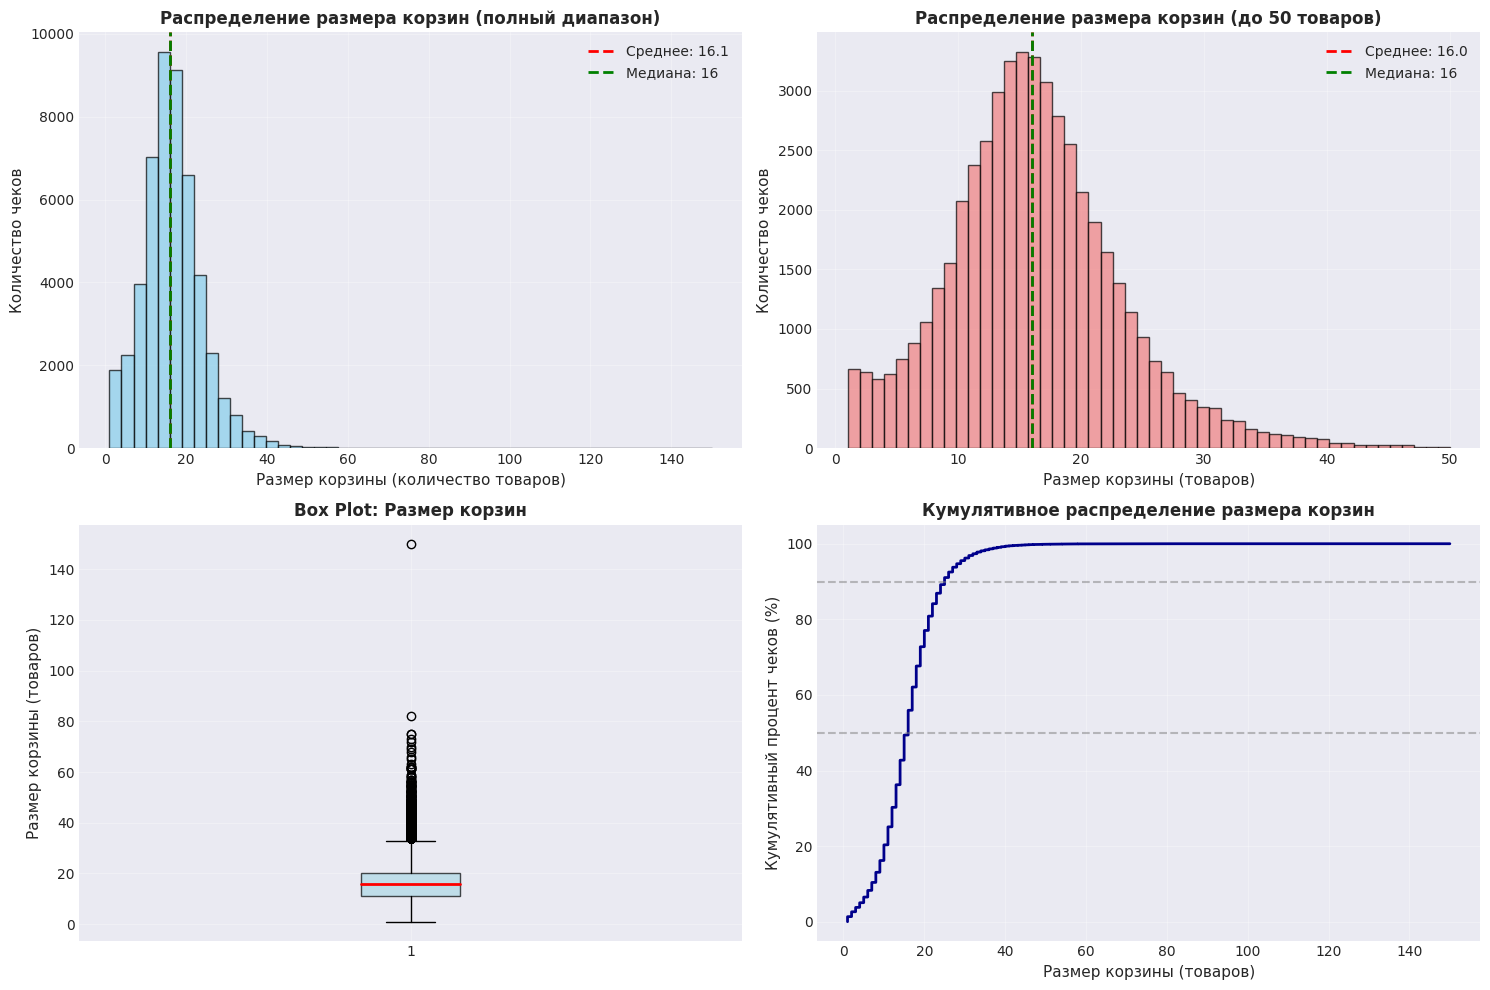

In [15]:
print("АНАЛИЗ СТРУКТУРЫ КОРЗИН И ПОПУЛЯРНЫХ ТОВАРОВ")


print("\n АНАЛИЗ РАЗМЕРА КОРЗИН")

basket_sizes = df.groupby('cheque_id')['name'].count()

# Статистика
print(f"\n Статистика размера корзин:")
print(f"   Среднее: {basket_sizes.mean():.2f} товаров")
print(f"   Медиана: {basket_sizes.median():.0f} товаров")
print(f"   Mode (мода): {basket_sizes.mode().values[0]:.0f} товаров")
print(f"   Стд отклонение: {basket_sizes.std():.2f}")
print(f"   Min: {basket_sizes.min()}")
print(f"   Max: {basket_sizes.max()}")
print(f"   25 перцентиль: {basket_sizes.quantile(0.25):.0f}")
print(f"   75 перцентиль: {basket_sizes.quantile(0.75):.0f}")

# Гистограмма размера корзин
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Гистограмма всех корзин
axes[0, 0].hist(basket_sizes, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(basket_sizes.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {basket_sizes.mean():.1f}')
axes[0, 0].axvline(basket_sizes.median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {basket_sizes.median():.0f}')
axes[0, 0].set_xlabel('Размер корзины (количество товаров)', fontsize=11)
axes[0, 0].set_ylabel('Количество чеков', fontsize=11)
axes[0, 0].set_title('Распределение размера корзин (полный диапазон)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

#Гистограмма без выбросов (до 50 товаров)
basket_sizes_trimmed = basket_sizes[basket_sizes <= 50]
axes[0, 1].hist(basket_sizes_trimmed, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(basket_sizes_trimmed.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {basket_sizes_trimmed.mean():.1f}')
axes[0, 1].axvline(basket_sizes_trimmed.median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {basket_sizes_trimmed.median():.0f}')
axes[0, 1].set_xlabel('Размер корзины (товаров)', fontsize=11)
axes[0, 1].set_ylabel('Количество чеков', fontsize=11)
axes[0, 1].set_title('Распределение размера корзин (до 50 товаров)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

#Box plot
axes[1, 0].boxplot([basket_sizes], vert=True, patch_artist=True, 
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('Размер корзины (товаров)', fontsize=11)
axes[1, 0].set_title('Box Plot: Размер корзин', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Кумулятивное распределение
sorted_sizes = np.sort(basket_sizes)
cumulative = np.arange(1, len(sorted_sizes) + 1) / len(sorted_sizes) * 100
axes[1, 1].plot(sorted_sizes, cumulative, linewidth=2, color='darkblue')
axes[1, 1].axhline(50, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axhline(90, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Размер корзины (товаров)', fontsize=11)
axes[1, 1].set_ylabel('Кумулятивный процент чеков (%)', fontsize=11)
axes[1, 1].set_title('Кумулятивное распределение размера корзин', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ТОП-20 САМЫХ ПОПУЛЯРНЫХ ТОВАРОВ

Место  Товар                                                   Встреч   %     
1      МАГНИТ Пакет-майка большой 15кг                         31013    3.85%
2      БАНАНЫ 1кг                                              10257    1.27%
3      МАНДАРИНЫ 1кг                                           8837     1.10%
4      Огурцы Среднеплодные 1кг                                6236     0.77%
5      ТОМАТЫ 1кг                                              5792     0.72%
6      ЛУК репчатый 1кг                                        5718     0.71%
7      ТС2 Сахар-песок белый кристаллический фас 1кг           4810     0.60%
8      ЯБЛОКИ новый урожай 1кг                                 4380     0.54%
9      Цыпленок бройлер охл. 1 кат. Поли/уп 1кг :13            4129     0.51%
10     Яйцо столовое С1 10шт бокс :20                          4121     0.51%
11     МАГНИТ Пакет-майка малый 5кг                            3857     0.48%
12     ЛИМОНЫ 1кг             

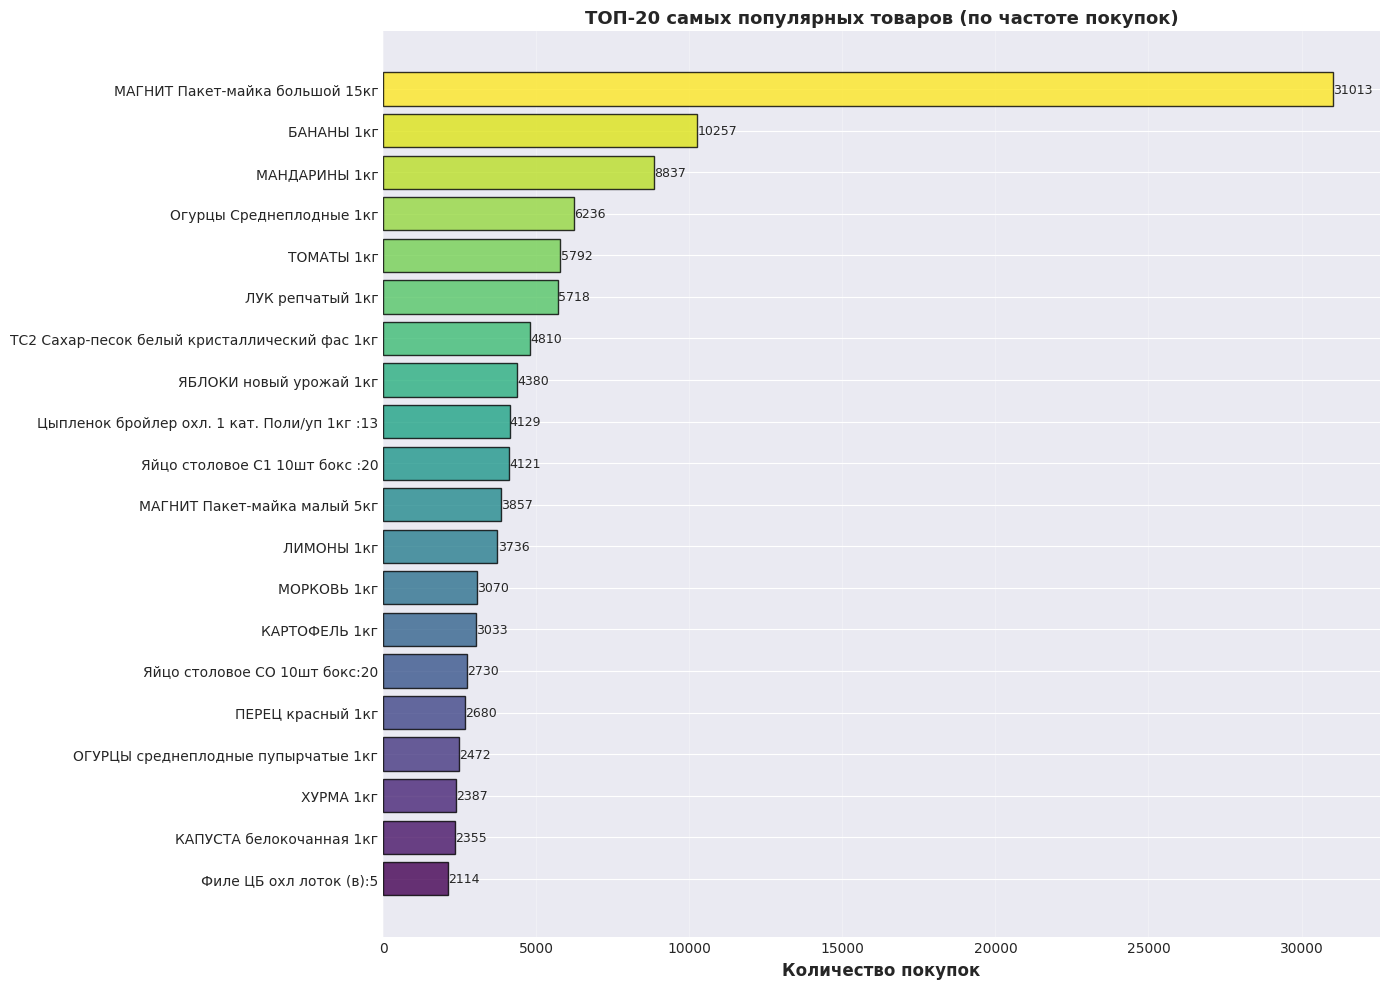

In [16]:
print("ТОП-20 САМЫХ ПОПУЛЯРНЫХ ТОВАРОВ")

# Считаем частоту товаров
product_freq = df['name'].value_counts().head(20)

print(f"\n{'Место':<6} {'Товар':<55} {'Встреч':<8} {'%':<6}")
for idx, (product, count) in enumerate(product_freq.items(), 1):
    percentage = (count / len(df)) * 100
    # Сокращаем название товара до 50 символов
    product_short = product[:50] + "..." if len(product) > 50 else product
    print(f"{idx:<6} {product_short:<55} {count:<8} {percentage:.2f}%")

# Топ-20 товаров
fig, ax = plt.subplots(figsize=(14, 10))

products = product_freq.index[::-1]
counts = product_freq.values[::-1]

colors = plt.cm.viridis(np.linspace(0, 1, len(products)))
bars = ax.barh(range(len(products)), counts, color=colors, edgecolor='black', alpha=0.8)

# Добавим значения на полосы
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count + 5, i, f'{count}', va='center', fontsize=9)

ax.set_yticks(range(len(products)))
ax.set_yticklabels([p[:60] + "..." if len(p) > 60 else p for p in products], fontsize=10)
ax.set_xlabel('Количество покупок', fontsize=12, fontweight='bold')
ax.set_title('ТОП-20 самых популярных товаров (по частоте покупок)', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

ТОП-10 КАТЕГОРИЙ (УРОВЕНЬ 0)


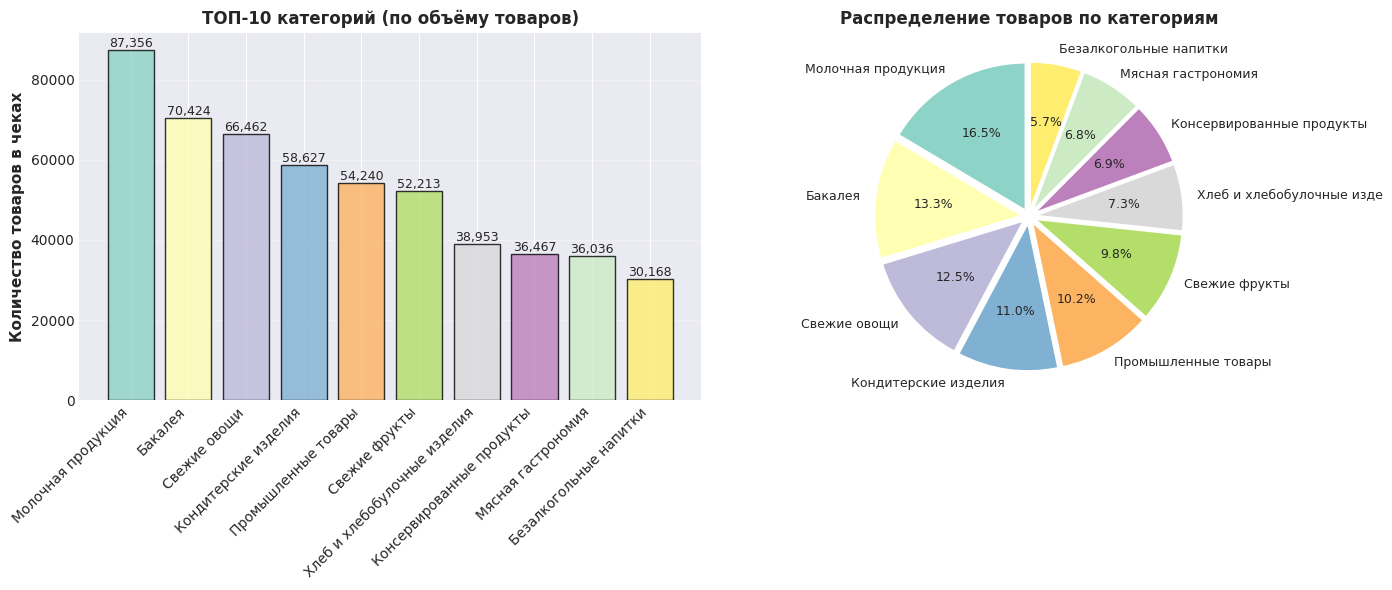

In [17]:
print("ТОП-10 КАТЕГОРИЙ (УРОВЕНЬ 0)")

category_freq = df['art_grp_lvl_0_name'].value_counts().head(10)

# Топ-10 категорий
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
categories = category_freq.index
counts = category_freq.values

colors_cat = plt.cm.Set3(np.linspace(0, 1, len(categories)))
bars = axes[0].bar(range(len(categories)), counts, color=colors_cat, edgecolor='black', alpha=0.8)

# Добавить значения на столбцы
for bar, count in zip(bars, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}',
                ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(range(len(categories)))
axes[0].set_xticklabels([c[:30] for c in categories], rotation=45, ha='right', fontsize=10)
axes[0].set_ylabel('Количество товаров в чеках', fontsize=11, fontweight='bold')
axes[0].set_title('ТОП-10 категорий (по объёму товаров)', fontsize=12, fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)

# Pie chart
explode = [0.05] * len(categories)
wedges, texts, autotexts = axes[1].pie(counts, labels=[c[:25] for c in categories], 
                                         autopct='%1.1f%%', startangle=90,
                                         colors=colors_cat, explode=explode,
                                         textprops={'fontsize': 9})
axes[1].set_title('Распределение товаров по категориям', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

АНАЛИЗ СО-ВСТРЕЧАЕМОСТИ ТОВАРОВ

Место  Товар 1                                       Товар 2                                       Раз   
1      БАНАНЫ 1кг                                    МАГНИТ Пакет-майка большой 15кг               6734  
2      МАГНИТ Пакет-майка большой 15кг               МАНДАРИНЫ 1кг                                 5538  
3      МАГНИТ Пакет-майка большой 15кг               Огурцы Среднеплодные 1кг                      4066  
4      ЛУК репчатый 1кг                              МАГНИТ Пакет-майка большой 15кг               3801  
5      МАГНИТ Пакет-майка большой 15кг               ТОМАТЫ 1кг                                    3795  
6      МАГНИТ Пакет-майка большой 15кг               ТС2 Сахар-песок белый кристаллический фас ... 3258  
7      БАНАНЫ 1кг                                    МАНДАРИНЫ 1кг                                 3017  
8      МАГНИТ Пакет-майка большой 15кг               Цыпленок бройлер охл. 1 кат. Поли/уп 1кг :... 2736  
9      Огурцы

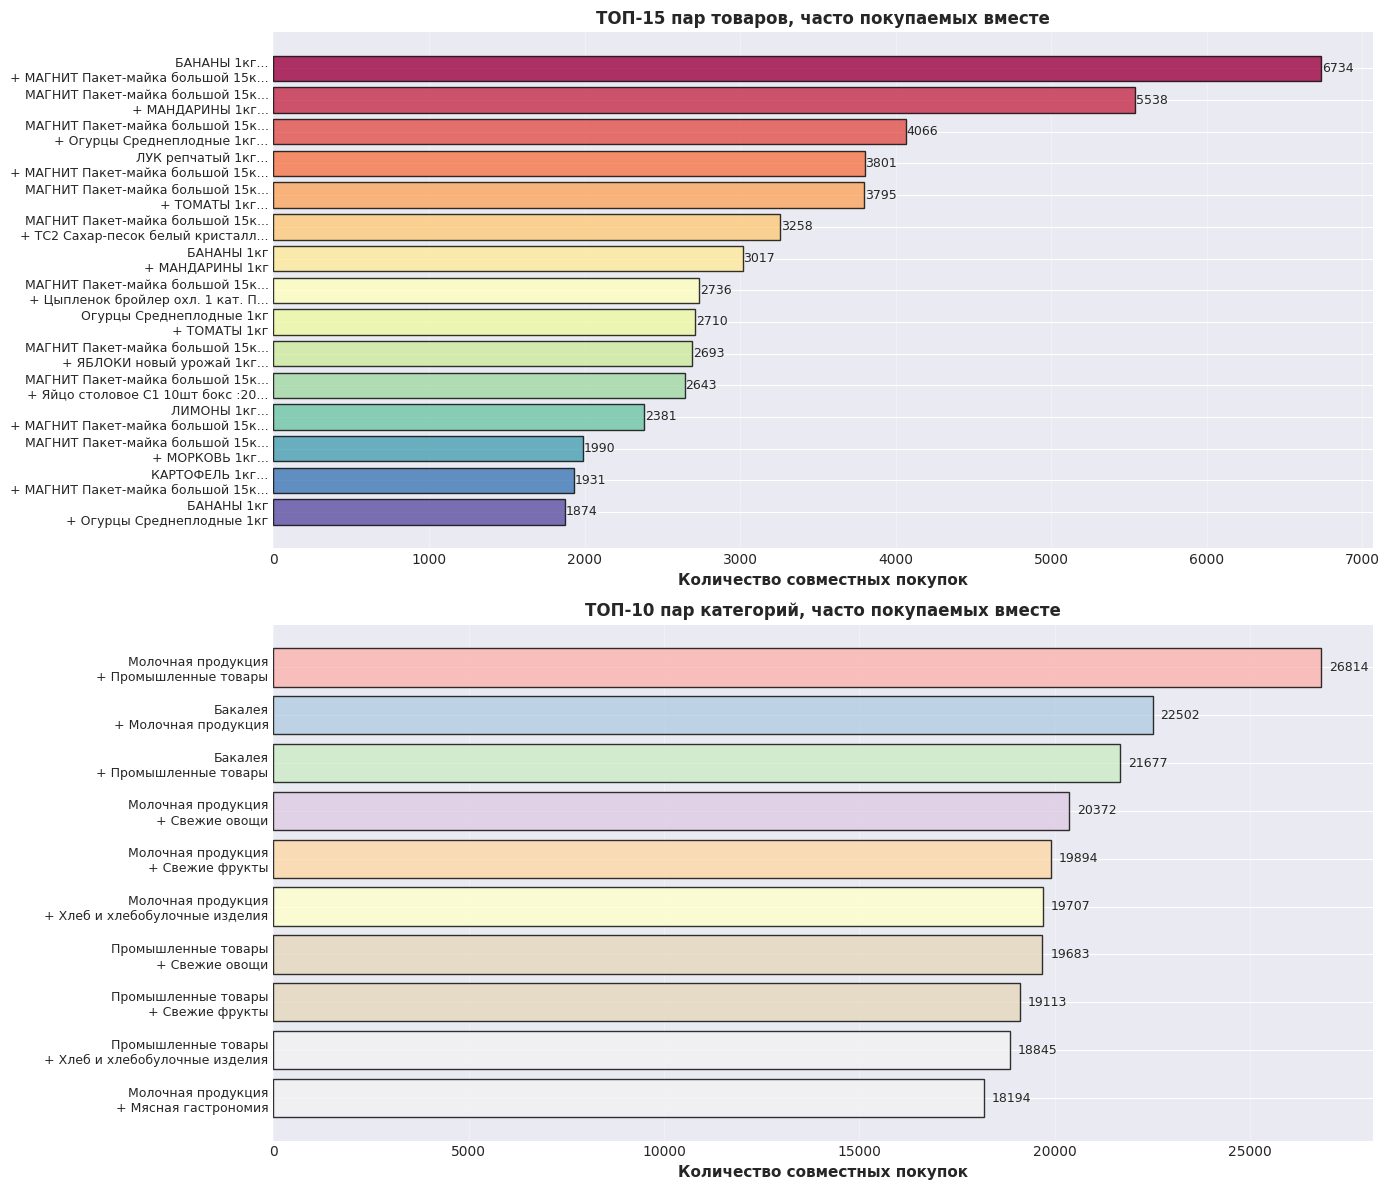

In [18]:
print("АНАЛИЗ СО-ВСТРЕЧАЕМОСТИ ТОВАРОВ")

# Для каждой корзины: найти все пары товаров
pairs = []
pair_categories = []  # Для анализа по категориям

for cheque_id, group in df.groupby('cheque_id'):
    basket_items = group['name'].unique()
    basket_categories = group['art_grp_lvl_0_name'].unique()
    
    if len(basket_items) >= 2:
        # Все пары товаров
        for pair in combinations(sorted(basket_items), 2):
            pairs.append(pair)
        
        # Все пары категорий
        if len(basket_categories) >= 2:
            for pair_cat in combinations(sorted(basket_categories), 2):
                pair_categories.append(pair_cat)

# Топ пары товаров
pair_freq = Counter(pairs)
top_pairs = pair_freq.most_common(15)

print(f"\n{'Место':<6} {'Товар 1':<45} {'Товар 2':<45} {'Раз':<6}")
for idx, ((item1, item2), count) in enumerate(top_pairs, 1):
    item1_short = item1[:42] + "..." if len(item1) > 42 else item1
    item2_short = item2[:42] + "..." if len(item2) > 42 else item2
    print(f"{idx:<6} {item1_short:<45} {item2_short:<45} {count:<6}")

# Топ пары категорий
pair_cat_freq = Counter(pair_categories)
top_pairs_cat = pair_cat_freq.most_common(10)

print(f"\n\n{'Место':<6} {'Категория 1':<40} {'Категория 2':<40} {'Раз':<8}")
for idx, ((cat1, cat2), count) in enumerate(top_pairs_cat, 1):
    cat1_short = cat1[:35] + "..." if len(cat1) > 35 else cat1
    cat2_short = cat2[:35] + "..." if len(cat2) > 35 else cat2
    print(f"{idx:<6} {cat1_short:<40} {cat2_short:<40} {count:<8}")

# Топ пары товаров
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Топ пары товаров
pair_names = [f"{p[0][:30]}...\n+ {p[1][:30]}..." if (len(p[0]) > 30 or len(p[1]) > 30) 
              else f"{p[0]}\n+ {p[1]}" for p, _ in top_pairs]
pair_counts = [count for _, count in top_pairs]

colors_pairs = plt.cm.Spectral(np.linspace(0, 1, len(pair_names)))
bars = axes[0].barh(range(len(pair_names)), pair_counts[::-1], color=colors_pairs[::-1], 
                     edgecolor='black', alpha=0.8)

# Добавить значения
for i, (bar, count) in enumerate(zip(bars, pair_counts[::-1])):
    axes[0].text(count + 5, i, f'{count}', va='center', fontsize=9)

axes[0].set_yticks(range(len(pair_names)))
axes[0].set_yticklabels(pair_names[::-1], fontsize=9)
axes[0].set_xlabel('Количество совместных покупок', fontsize=11, fontweight='bold')
axes[0].set_title('ТОП-15 пар товаров, часто покупаемых вместе', fontsize=12, fontweight='bold')
axes[0].grid(True, axis='x', alpha=0.3)

# Топ пары категорий
pair_cat_names = [f"{p[0]}\n+ {p[1]}" for p, _ in top_pairs_cat]
pair_cat_counts = [count for _, count in top_pairs_cat]

colors_cat_pairs = plt.cm.Pastel1(np.linspace(0, 1, len(pair_cat_names)))
bars2 = axes[1].barh(range(len(pair_cat_names)), pair_cat_counts[::-1], 
                      color=colors_cat_pairs[::-1], edgecolor='black', alpha=0.8)

# Добавить значения
for i, (bar, count) in enumerate(zip(bars2, pair_cat_counts[::-1])):
    axes[1].text(count + 200, i, f'{count}', va='center', fontsize=9)

axes[1].set_yticks(range(len(pair_cat_names)))
axes[1].set_yticklabels(pair_cat_names[::-1], fontsize=9)
axes[1].set_xlabel('Количество совместных покупок', fontsize=11, fontweight='bold')
axes[1].set_title('ТОП-10 пар категорий, часто покупаемых вместе', fontsize=12, fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")

print(f"\n Всего уникальных пар товаров: {len(pair_freq):,}")
print(f" Всего уникальных пар категорий: {len(pair_cat_freq):,}")

# Средняя частота пары товаров
avg_pair_freq = np.mean(list(pair_freq.values()))
print(f"\n Средняя частота пары товаров: {avg_pair_freq:.2f}")

# Процент пар, которые встречаются только 1 раз
single_pairs = sum(1 for count in pair_freq.values() if count == 1)
single_pairs_pct = (single_pairs / len(pair_freq)) * 100
print(f" Пары товаров, встречающиеся только 1 раз: {single_pairs:,} ({single_pairs_pct:.1f}%)")

# Пары, встречающиеся более 100 раз
frequent_pairs = sum(1 for count in pair_freq.values() if count > 100)
print(f" Пары товаров, встречающиеся более 100 раз: {frequent_pairs:,}")


ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА

 Всего уникальных пар товаров: 4,203,836
 Всего уникальных пар категорий: 617

 Средняя частота пары товаров: 1.76
 Пары товаров, встречающиеся только 1 раз: 3,353,200 (79.8%)
 Пары товаров, встречающиеся более 100 раз: 2,083


При подготовке данных мы исключили позиции, относящиеся к техническому обслуживанию покупки, в частности «пакет‑майка МАГНИТ». Данный товар присутствует в большинстве чеков и входит в практически все частотные пары совместных покупок, что делает его аналогом высокочастотного стоп‑слова в задачах NLP. Пакет не отражает никакого осмысленного фактора вариации товара (категорию, ценовой сегмент, функциональное назначение) и лишь кодирует факт крупной покупки. Сохранение подобных позиций приводило бы к появлению в эмбеддингах сильного «hub»‑узла и спурионных связей, затрудняя интерпретацию измерений. Поэтому все строки с данным товаром были исключены перед обучением моделей.

In [51]:
df_clean = df.copy()

# Фильтрация пакетов-маек по name (можно при желании добавить art_grp_name)
mask_paket = df_clean['name'].str.contains('Пакет-майка', case=False, na=False)

print(f"До фильтрации: {len(df_clean):,} строк, {df_clean['name'].nunique():,} уникальных товаров")
print(f"Строк с пакетами-маиками: {mask_paket.sum():,}")

df_clean = df_clean[~mask_paket].reset_index(drop=True)

print(f"После фильтрации: {len(df_clean):,} строк, {df_clean['name'].nunique():,} уникальных товаров")

До фильтрации: 804,737 строк, 27,224 уникальных товаров
Строк с пакетами-маиками: 35,049
После фильтрации: 769,688 строк, 27,220 уникальных товаров


In [52]:
# Работаем уже с df_clean
cat_cols = [
    'art_grp_lvl_0_name',
    'art_grp_lvl_1_name',
    'art_grp_lvl_2_name',
    'art_grp_lvl_3_name',
    'art_grp_lvl_4_name'
]

print("АНАЛИЗ ИЕРАРХИИ КАТЕГОРИЙ")

# Уникальные значения и топ-5 по частоте на каждом уровне
summary_rows = []

for col in cat_cols:
    vc = df_clean[col].value_counts()
    n_unique = vc.nunique()
    top5 = vc.head(5)

    print(f"\n {col}")
    print(f"   Уникальных значений: {len(vc):,}")
    print("   Топ‑5 категорий:")
    for name, cnt in top5.items():
        pct = cnt / len(df_clean) * 100
        print(f"   - {name} — {cnt:,} строк ({pct:.2f}%)")

    summary_rows.append({
        "Уровень": col,
        "Уникальных категорий": len(vc),
        "Доля топ‑1, %": round(vc.iloc[0] / len(df_clean) * 100, 2),
        "Доля топ‑5, %": round(vc.head(5).sum() / len(df_clean) * 100, 2)
    })

# Сводная табличка по уровням
summary_df = pd.DataFrame(summary_rows)
print("\n\nСводка по уровням категорий:")
display(summary_df)

# Примеры полных путей категорий для случайных товаров
print("\nПримеры полных путей категорий (5 случайных товаров):")
sample_paths = df_clean[
    ['name'] + cat_cols
].drop_duplicates().sample(5, random_state=42)

display(sample_paths)


АНАЛИЗ ИЕРАРХИИ КАТЕГОРИЙ

 art_grp_lvl_0_name
   Уникальных значений: 36
   Топ‑5 категорий:
   - Молочная продукция — 87,356 строк (11.35%)
   - Бакалея — 70,424 строк (9.15%)
   - Свежие овощи — 66,462 строк (8.63%)
   - Кондитерские изделия — 58,627 строк (7.62%)
   - Свежие фрукты — 52,213 строк (6.78%)

 art_grp_lvl_1_name
   Уникальных значений: 185
   Топ‑5 категорий:
   - Хлеб и хлебобулочные изделия — 38,857 строк (5.05%)
   - Корнеплоды, зелень и прочие овощи — 36,128 строк (4.69%)
   - Цитрусовые, семечковые и прочие плоды — 32,872 строк (4.27%)
   - Тепличные овощи, грибы — 30,334 строк (3.94%)
   - Колбасы — 22,374 строк (2.91%)

 art_grp_lvl_2_name
   Уникальных значений: 631
   Топ‑5 категорий:
   - Цитрусовые плоды — 18,428 строк (2.39%)
   - Молоко коровье — 16,580 строк (2.15%)
   - Конфеты шоколадные (вес) — 15,812 строк (2.05%)
   - Полутвердые сыры — 14,354 строк (1.86%)
   - Майонез — 13,662 строк (1.78%)

 art_grp_lvl_3_name
   Уникальных значений: 1,369
   Топ‑

,Уровень,Уникальных категорий,"Доля топ‑1, %","Доля топ‑5, %"
0,art_grp_lvl_0_name,36,11.35,43.53
1,art_grp_lvl_1_name,185,5.05,20.86
2,art_grp_lvl_2_name,631,2.39,10.24
3,art_grp_lvl_3_name,1369,1.74,7.94
4,art_grp_lvl_4_name,1543,1.74,7.94



Примеры полных путей категорий (5 случайных товаров):


,name,art_grp_lvl_0_name,art_grp_lvl_1_name,art_grp_lvl_2_name,art_grp_lvl_3_name,art_grp_lvl_4_name
601238,СМАК Французские улочки Бриошь с вишневой начи...,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,Мелкоштучные хлебные изделия,Сдобные изделия с начинкой,Сдобные изделия с начинкой
413455,ДЫМ ДЫМЫЧ Сосиски Российские и/о кат Б 500г мя...,Мясная гастрономия,"Сосиски, сардельки",Сосиски,Сосиски,Сосиски
682278,Формы алюминиевые круглые 2шт (Импэкс):44,Промышленные товары,Товары для Дома,Упаковка для выпечки и хранения продуктов,Бумага для выпечки,Бумага для выпечки
17496,СОБРАНИЕ Блек КС Суперслим Сигареты МРЦ 193(Дж...,Табачные изделия,Сигареты,Сигареты,Сигареты,Сигареты
271061,СИСИ Колготки жен Миними ЛАУРА Микс 40Д:10/100,Промышленные товары,Нижнее белье,Чулочно-носочные изделия,Колготки,Колготки женские 40Д


In [53]:
# Финальный набор столбцов для работы
TEXT_COLS = ['name', 'art_grp_full_name']

HIER_COLS = [
    'art_pricing_model',   # Макро: модель ценообразования
    'art_grp_lvl_0_name',   # Макро-категория
    'art_grp_lvl_1_name',   # Подкатегория
    'art_grp_lvl_2_name'   # Детальная (опционально)
]

# Все нужные столбцы
COLS_NEEDED = ['cheque_id', 'contact_id', 'quantity', 'summ_discounted'] + TEXT_COLS + HIER_COLS

# Финальный датафрейм для работы
df_final = df_clean[COLS_NEEDED].copy()

print(f"Финальный датафрейм: {len(df_final):,} строк, {len(df_final.columns)} столбцов")
print(f"Столбцы: {list(df_final.columns)}")


Финальный датафрейм: 769,688 строк, 10 столбцов
Столбцы: ['cheque_id', 'contact_id', 'quantity', 'summ_discounted', 'name', 'art_grp_full_name', 'art_pricing_model', 'art_grp_lvl_0_name', 'art_grp_lvl_1_name', 'art_grp_lvl_2_name']


In [54]:
df_final.head(2)

,cheque_id,contact_id,quantity,summ_discounted,name,art_grp_full_name,art_pricing_model,art_grp_lvl_0_name,art_grp_lvl_1_name,art_grp_lvl_2_name
0,5.854260e+09,8299439.0,1.0,2017.65,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Продукты,Крепкий алкоголь,Коньяк,Коньяк Армения
1,5.880308e+09,19290093.0,1.0,2993.15,"Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(А...",Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Продукты,Крепкий алкоголь,Коньяк,Коньяк Армения


In [55]:
print(df_final.shape[0])
df_final = df_final[~df_final.cheque_id.isin(bad_treshold_lst)]
print(df_final.shape[0])

769688
768876


In [56]:
print("ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ МОДЕЛЕЙ")

print("ПРЕДОБРАБОТКА ТЕКСТА")

def clean_text_light(text):
    """
    Лёгкая очистка текста (без агрессивного стемминга).
    Сохраняем бренды, числа, основные характеристики.
    """
    if pd.isna(text):
        return ""
    
    # Приводим к нижнему регистру
    text = str(text).lower()
    
    # Убираем лишние пробелы
    text = re.sub(r'\s+', ' ', text)
    
    # Убираем спецсимволы, но оставляем цифры, буквы, пробелы, дефисы
    text = re.sub(r'[^\w\s\-]', ' ', text)
    
    # Убираем множественные дефисы
    text = re.sub(r'-+', '-', text)
    
    # Trim
    text = text.strip()
    
    return text

# Применяем очистку к name
df_final['name_clean'] = df_final['name'].progress_apply(clean_text_light)

# Примеры очистки
print("Примеры очистки текста (5 случайных):")
sample_cleaning = df_final[['name', 'name_clean']].drop_duplicates().sample(5, random_state=42)
for idx, row in sample_cleaning.iterrows():
    print(f"  ДО:  {row['name'][:70]}")
    print(f"  ПОСЛЕ: {row['name_clean'][:70]}\n")

print("\n СОЗДАНИЕ МАППИНГОВ ТОВАР ↔ ID")

# Уникальные товары по name, потому что clean может склеить разные товары в один
unique_products = df_final[['name', 'name_clean'] + HIER_COLS + ['art_grp_full_name']].drop_duplicates(subset=['name'])

# Создаём ID для каждого уникального товара
unique_products = unique_products.reset_index(drop=True)
unique_products['product_id'] = unique_products.index

print(f" Уникальных товаров: {len(unique_products):,}")
print(f"   (по оригинальному name, с сохранением метаданных)")

# Маппинг: name - product_id
name_to_id = dict(zip(unique_products['name'], unique_products['product_id']))

# Маппинг: product_id - метаданные
product_metadata = unique_products.set_index('product_id').to_dict('index')

print(f"\nПримеры product_id:")
for i in range(3):
    pid = unique_products.iloc[i]['product_id']
    pname = unique_products.iloc[i]['name']
    print(f"   ID {pid}: {pname[:60]}")

print("\n\n ФОРМИРОВАНИЕ BASKETS")

# Добавляем product_id в основной датафрейм
df_final['product_id'] = df_final['name'].map(name_to_id)

# Проверка
assert df_final['product_id'].isna().sum() == 0, "Есть товары без ID!"

baskets_dict = defaultdict(list)
for _, row in df_final.iterrows():
    cheque_id = row['cheque_id']
    product_id = row['product_id']
    quantity = row['quantity']
    
    # Добавляем товар quantity раз
    # Если quantity=2, товар появится 2 раза в корзине
    for _ in range(int(quantity)):
        baskets_dict[cheque_id].append(product_id)

# Конвертируем в список списков
baskets = list(baskets_dict.values())

print(f" Сформировано {len(baskets):,} корзин")
print(f"   Средний размер корзины: {np.mean([len(b) for b in baskets]):.2f} товаров")
print(f"   Медианный размер: {np.median([len(b) for b in baskets]):.0f} товаров")

# Примеры корзин (первые 3)
print("\n Примеры корзин (первые 3, показываем ID):")
for i, basket in enumerate(baskets[:3], 1):
    print(f"\n  Корзина {i} ({len(basket)} товаров):")
    print(f"    Product IDs: {basket[:10]}{'...' if len(basket) > 10 else ''}")
    
    # Показываем названия первых 5 товаров
    print(f"    Названия товаров:")
    for pid in basket[:5]:
        pname = product_metadata[pid]['name']
        print(f"      - {pname[:60]}")

print("\n\nАЛЬТЕРНАТИВНЫЙ ФОРМАТ: BASKETS С NAME_CLEAN")

# Для некоторых моделей может понадобиться формат со словами (не ID)
baskets_dict_name = defaultdict(list)
for _, row in df_final.iterrows():
    cheque_id = row['cheque_id']
    name_clean = row['name_clean']
    quantity = row['quantity']
    
    for _ in range(int(quantity)):
        baskets_dict_name[cheque_id].append(name_clean)

baskets_name = list(baskets_dict_name.values())

print(f" Сформировано {len(baskets_name):,} корзин (формат: name_clean)")
print("\n Пример корзины (формат name_clean):")
print(f"  Корзина 1 ({len(baskets_name[0])} товаров):")
for item in baskets_name[0][:5]:
    print(f"    - {item[:60]}")

print("\n\nФИНАЛЬНАЯ СТАТИСТИКА")

basket_sizes = [len(b) for b in baskets]

stats = {
    "Всего чеков (корзин)": len(baskets),
    "Уникальных товаров (product_id)": len(unique_products),
    "Всего строк транзакций": len(df_final),
    "Средний размер корзины": round(np.mean(basket_sizes), 2),
    "Медианный размер корзины": int(np.median(basket_sizes)),
    "Min размер корзины": min(basket_sizes),
    "Max размер корзины": max(basket_sizes),
    "Стд отклонение размера": round(np.std(basket_sizes), 2)
}

print("\n СВОДКА:")
for key, value in stats.items():
    print(f"   {key:<35}: {value:>10,}" if isinstance(value, int) else f"   {key:<35}: {value:>10}")

print("\n\nСОХРАНЕНИЕ")

# Сохраняем для последующего использования
import pickle

# Baskets (ID)
with open('../data/baskets_product_id.pkl', 'wb') as f:
    pickle.dump(baskets, f)
print(" Сохранено: ../data/baskets_product_id.pkl")

# Baskets (name_clean)
with open('../data/baskets_name_clean.pkl', 'wb') as f:
    pickle.dump(baskets_name, f)
print(" Сохранено: ../data/baskets_name_clean.pkl")

# Product metadata (для интерпретации)
with open('../data/product_metadata.pkl', 'wb') as f:
    pickle.dump(product_metadata, f)
print(" Сохранено: ../data/product_metadata.pkl")

# Unique products DataFrame
unique_products.to_csv('../data/unique_products.csv', index=False)
print(" Сохранено: ../data/unique_products.csv")
del df_final['name']
# Финальный датафрейм
df_final.to_csv('../data/df_final_prepared.csv', index=False)
print(" Сохранено: ../data/df_final_prepared.csv")


print("\nГотовы к обучению моделей:")
print("  - baskets_product_id.pkl — для Word2Vec с ID")
print("  - baskets_name_clean.pkl — для Word2Vec с текстом")
print("  - product_metadata.pkl — метаданные для интерпретации")
print("  - unique_products.csv — таблица товаров с категориями")


ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ МОДЕЛЕЙ
ПРЕДОБРАБОТКА ТЕКСТА


100%|██████████| 768876/768876 [00:05<00:00, 133175.57it/s]


Примеры очистки текста (5 случайных):
  ДО:  VICI Фаворит Коктейль из морепрод в рассоле 400г пл/бан:6
  ПОСЛЕ: vici фаворит коктейль из морепрод в рассоле 400г пл бан 6

  ДО:  Коньяк АПШЕРОН 4 года 40% 0,5л (МАВЗ):6
  ПОСЛЕ: коньяк апшерон 4 года 40  0 5л  мавз  6

  ДО:  БЕЛАЯ ДОЛИНА Мороженое ЗМЖ черника рож0,07кг(Энгельсский):35
  ПОСЛЕ: белая долина мороженое змж черника рож0 07кг энгельсский  35

  ДО:  СОБРАНИЕ Блек КС Суперслим Сигареты МРЦ 193(ДжТИ):10/500
  ПОСЛЕ: собрание блек кс суперслим сигареты мрц 193 джти  10 500

  ДО:  ЕСТЬ Паштет Сливочный 0,18кг п/о (Динской):28
  ПОСЛЕ: есть паштет сливочный 0 18кг п о  динской  28


 СОЗДАНИЕ МАППИНГОВ ТОВАР ↔ ID
 Уникальных товаров: 27,212
   (по оригинальному name, с сохранением метаданных)

Примеры product_id:
   ID 0: Коньяк армянский АРЕВИК 5лет 40% 0,5л под/уп(Армения):6
   ID 1: ВНИМИ-СИБИРЬ Кефир 2,5% 900г ф/п(Тюкалинский МСК)
   ID 2: Paclan Мешки д/мус Standart 8,5мкм 60л 20шт ЭР(Седо):42


 ФОРМИРОВАНИЕ BASKETS
 Сформ

In [57]:
df_final.head(2)

,cheque_id,contact_id,quantity,summ_discounted,art_grp_full_name,art_pricing_model,art_grp_lvl_0_name,art_grp_lvl_1_name,art_grp_lvl_2_name,name_clean,product_id
0,5.854260e+09,8299439.0,1.0,2017.65,Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Продукты,Крепкий алкоголь,Коньяк,Коньяк Армения,коньяк армянский аревик 5лет 40 0 5л под уп а...,0
1,5.880308e+09,19290093.0,1.0,2993.15,Крепкий алкоголь•Коньяк•Коньяк Армения•Коньяк ...,Продукты,Крепкий алкоголь,Коньяк,Коньяк Армения,коньяк армянский аревик 5лет 40 0 5л под уп а...,0
